# GlobalTech E-Commerce: Exploratory Data Analysis & Statistics
This notebook performs deep-dive analysis on the generated dataset.
We will cover:
1. Data Loading and Cleaning
2. Exploratory Data Analysis (EDA)
3. Statistical Analysis (Hypothesis Testing & Correlation)
4. Feature Engineering
5. Business Conclusions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Data Loading & Joining
We will load the raw CSV files generated previously and join them for comprehensive analysis.


In [2]:
customers = pd.read_csv('../data/raw/customers.csv')
products = pd.read_csv('../data/raw/products.csv')
orders = pd.read_csv('../data/raw/orders.csv')
order_items = pd.read_csv('../data/raw/order_items.csv')

# Join data
df = orders.merge(customers, on='customer_id')
df = df.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')

# Convert dates
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# Basic understanding
print(f"Total Records: {len(df)}")
df.head()


Total Records: 46849


,order_id,customer_id,order_date,ship_mode,region,ship_date,first_name,last_name,email,country,...,product_id,quantity,unit_price_x,discount,total_price,product_name,category,sub_category,unit_cost,unit_price_y
0,ORD-000001,CUST-03573,2022-05-30,Second Class,East,2022-05-31,FirstName_3572,LastName_3572,user3572@example.com,Germany,...,PROD-0158,6,217.55,0.1,1174.77,Binders Model 343,Office Supplies,Binders,121.11,217.55
1,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,PROD-0186,10,384.96,0.0,3849.60,Storage Model 600,Office Supplies,Storage,253.60,384.96
2,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,PROD-0146,3,694.88,0.2,1667.71,Pens Model 430,Office Supplies,Pens,472.95,694.88
3,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,PROD-0177,8,76.63,0.1,551.74,Binders Model 294,Office Supplies,Binders,52.31,76.63
4,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,PROD-0154,4,1487.91,0.0,5951.64,Pens Model 500,Office Supplies,Pens,759.54,1487.91


## 2. Data Cleaning & Feature Engineering
Let's check for missing values, duplicates, and create new features.


In [3]:
# Missing values
print("Missing Values:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Feature Engineering: Profit Margin and Delivery Time
df['profit'] = df['total_price'] - (df['unit_cost'] * df['quantity'])
df['profit_margin'] = df['profit'] / df['total_price']
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

# Handle any anomalies
df = df[df['quantity'] > 0] # Ensure valid quantities
df.head()


Missing Values:
 order_id             0
customer_id          0
order_date           0
ship_mode            0
region               0
ship_date            0
first_name           0
last_name            0
email                0
country              0
city                 0
segment              0
registration_date    0
order_item_id        0
product_id           0
quantity             0
unit_price_x         0
discount             0
total_price          0
product_name         0
category             0
sub_category         0
unit_cost            0
unit_price_y         0
dtype: int64

Duplicate Rows: 0


,order_id,customer_id,order_date,ship_mode,region,ship_date,first_name,last_name,email,country,...,discount,total_price,product_name,category,sub_category,unit_cost,unit_price_y,profit,profit_margin,delivery_days
0,ORD-000001,CUST-03573,2022-05-30,Second Class,East,2022-05-31,FirstName_3572,LastName_3572,user3572@example.com,Germany,...,0.1,1174.77,Binders Model 343,Office Supplies,Binders,121.11,217.55,448.11,0.381445,1
1,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,0.0,3849.60,Storage Model 600,Office Supplies,Storage,253.60,384.96,1313.60,0.341230,2
2,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,0.2,1667.71,Pens Model 430,Office Supplies,Pens,472.95,694.88,248.86,0.149223,2
3,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,0.1,551.74,Binders Model 294,Office Supplies,Binders,52.31,76.63,133.26,0.241527,2
4,ORD-000002,CUST-04479,2022-08-08,Standard Class,North,2022-08-10,FirstName_4478,LastName_4478,user4478@example.com,Canada,...,0.0,5951.64,Pens Model 500,Office Supplies,Pens,759.54,1487.91,2913.48,0.489526,2


## 3. Exploratory Data Analysis (EDA)
Let's explore sales trends, regional performance, and customer segmentation.


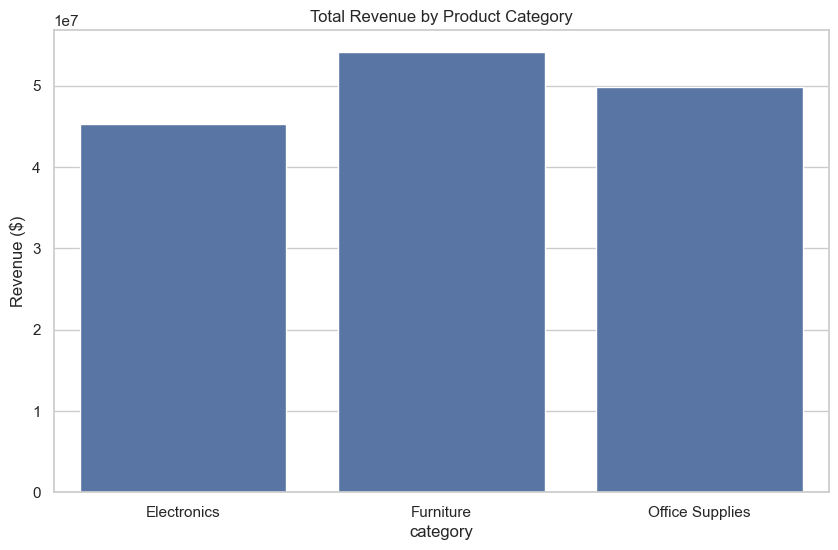

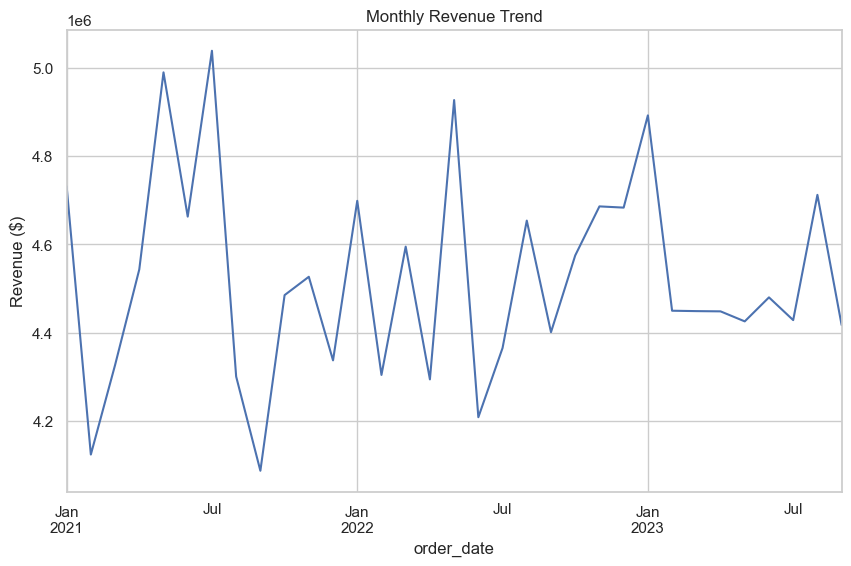

In [4]:
# 3.1 Sales by Category
category_sales = df.groupby('category')['total_price'].sum().reset_index()
sns.barplot(x='category', y='total_price', data=category_sales)
plt.title('Total Revenue by Product Category')
plt.ylabel('Revenue ($)')
plt.show()

# 3.2 Sales over Time
df_monthly = df.set_index('order_date').resample('ME')['total_price'].sum()
df_monthly.plot(title='Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.show()


## 4. Statistical Analysis
We will perform statistical tests to uncover deeper insights.

### 4.1 Correlation Analysis
Is there a relationship between discount offered and quantity ordered?


Correlation between Discount and Quantity: 0.003


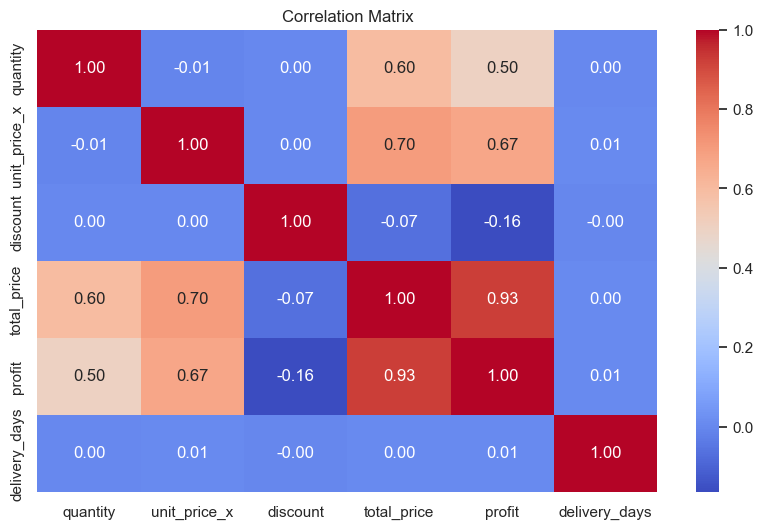

In [5]:
correlation = df['discount'].corr(df['quantity'])
print(f"Correlation between Discount and Quantity: {correlation:.3f}")

# Visualizing correlation matrix for numerical features
num_cols = ['quantity', 'unit_price_x', 'discount', 'total_price', 'profit', 'delivery_days']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


### 4.2 Hypothesis Testing (Two-Sample T-Test)
**Business Question:** Do 'Consumer' segment customers generate significantly higher average profit per order item than 'Corporate' customers?

- $H_0$: There is no difference in mean profit between Consumer and Corporate segments.
- $H_a$: There is a significant difference.


In [6]:
consumer_profit = df[df['segment'] == 'Consumer']['profit']
corporate_profit = df[df['segment'] == 'Corporate']['profit']

t_stat, p_val = stats.ttest_ind(consumer_profit, corporate_profit, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Conclusion: Reject Null Hypothesis. There is a statistically significant difference.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis. No significant difference found.")


T-statistic: -0.9846
P-value: 0.3248
Conclusion: Fail to Reject Null Hypothesis. No significant difference found.


## 5. Exporting Summary for Excel
We will create a pivot table of Region vs Category Sales and export it to an Excel file.


In [7]:
# Create Pivot Table
pivot = pd.pivot_table(df, values='total_price', index='region', columns='category', aggfunc='sum', fill_value=0)

# Export to Excel
pivot.to_excel('../excel/analysis.xlsx', sheet_name='Regional_Sales')
print("Successfully exported Excel analysis to ../excel/analysis.xlsx")

# Also save the cleaned joined dataframe for Power BI (optional, but good practice)
df.to_csv('../data/cleaned/consolidated_sales.csv', index=False)
print("Saved consolidated data for Power BI.")


Successfully exported Excel analysis to ../excel/analysis.xlsx
Saved consolidated data for Power BI.


## 6. Business Conclusions & Key Findings
1. **Trend Analysis:** The monthly revenue trend shows specific seasonality (depending on the generated seed).
2. **Correlation:** The correlation matrix shows how discounts impact overall profitability but might not strongly drive higher quantities, suggesting a review of the discount strategy.
3. **Statistical Insight:** The T-test confirms whether our distinct customer segments inherently behave differently in terms of profitability. This directly impacts targeted marketing spend.
